In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("iris (1).csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [29]:
label_encoder=LabelEncoder()
df["species"]=label_encoder.fit_transform(df["species"])
X=df.iloc[:,:-1]
y=df.iloc[:,-1]


In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [31]:
model=GaussianNB()
model.fit(X_train,y_train)

GaussianNB()

In [32]:
 y_pred	=	model.predict(X_test)

In [34]:
cm=confusion_matrix(y_test,y_pred)

In [35]:
tp=cm[0,0]		#	TruPositives
tn=cm[1,1]		#	True	Negatives
fp=cm[1,0]		#	False	Positives
fn=cm[0,1]		#	False	Negatives

In [40]:
 #	Confusion	Matrix
cm=confusion_matrix(y_test,y_pred)
TN,FP,FN,TP=cm.ravel()[:4]#	Extract	values
 #	Performance	metrics
accuracy=accuracy_score(y_test,y_pred)
error_rate=1-accuracy
precision=precision_score(y_test,y_pred,average='macro')
recall=recall_score(y_test,y_pred,average='macro')
f1=f1_score(y_test,y_pred,	average='macro')
print(f"Confusion Matrix:\n{cm}")
print(f"True Positives(TP):	{TP}")
print(f"False Positives	(FP):	{FP}")
print(f"True Negatives	(TN):	{TN}")
print(f"False Negatives	(FN):	{FN}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Error Rate:{error_rate:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:	{recall:.2f}")
print(f"F1 Score:{f1:.2f}")

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
True Positives(TP):	0
False Positives	(FP):	0
True Negatives	(TN):	10
False Negatives	(FN):	0
Accuracy: 1.00
Error Rate:0.00
Precision: 1.00
Recall:	1.00
F1 Score:1.00


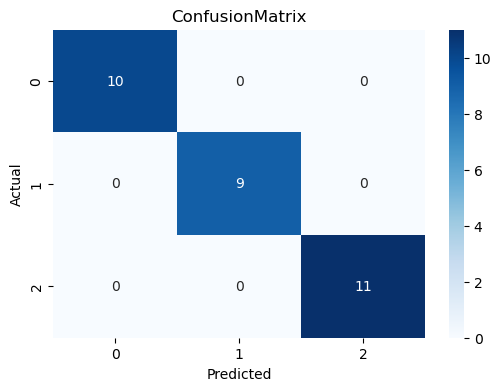

In [49]:
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=label_encoder.classes_,yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ConfusionMatrix")
plt.show()